# Unified Signal Architecture — v4 (Event Primary, Simplified)

## ปัญหาของ v3 (Hierarchical Tiers)

```
❌ Tier system สร้าง "damping chain":
   Tier 2 (event only): 8% × macro_scale(avg 0.44) = 3.5%  ← too small
   Tier 3 (tech only) : 5% × 0.44 = 2.2%                  ← negative EV drag
   Average deployed capital ≈ 15% → low absolute return
   Sharpe = -0.81 because tech-only trades erode event alpha
```

## v4 Architecture: Event Primary, Tech Boost

```
event_sig → base position (proportional to signal strength)
tech_sig  → size boost only when confirms (+30%) — NOT a gate
macro_sig → scale [0.40, 1.0]  (higher floor than before)

Formula:
  base_pos    = event_sig × 20%
  tech_mult   = 1.30 if tech_confirms else 1.0
  macro_scale = 0.40 + 0.60 × macro_sig
  position    = (base_pos × tech_mult × macro_scale).clip(0, 20%)

Signal types (for analysis only):
  event_boosted: event fires + tech confirms  → up to 20%
  event_only   : event fires, tech neutral    → up to 15%
  (no trade)   : no event signal              → skip
```

## Key changes from v3

```
✅ No tier complexity — single formula
✅ No tech-only trades — eliminates -EV drag completely
✅ Higher macro floor (40%) — more capital deployed in bear markets
✅ Strong event = large position (proportional, not capped at 15%)
✅ Tech is additive boost, not binary gate
```

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import yfinance as yf
from sklearn.ensemble import RandomForestClassifier
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
RNG = np.random.default_rng(42)

In [41]:
df_raw = pd.read_csv('../../data/processed/features/features_all.csv', parse_dates=['Date'])
df_raw = df_raw.sort_values(['symbol', 'Date']).reset_index(drop=True)
SYMBOLS  = sorted(df_raw['symbol'].unique())
FEATURES = [c for c in df_raw.columns if c not in
            ['Date', 'symbol', 'target', 'Open', 'High', 'Low', 'Close', 'Volume']]

print(f'Symbols : {SYMBOLS}')
print(f'Rows    : {len(df_raw):,}  |  Features: {len(FEATURES)}')
print(f'Dates   : {df_raw["Date"].min().date()} → {df_raw["Date"].max().date()}')

Symbols : ['AAPL', 'AMZN', 'BAC', 'JPM', 'MSFT', 'NVDA', 'TSLA']
Rows    : 16,212  |  Features: 25
Dates   : 2015-10-19 → 2024-12-31


---
## Section 1 — Build 3 Signal Components

ทุก component ออกมาเป็น **continuous [0, 1]** ไม่มี binary

In [42]:
def build_event_signal(df: pd.DataFrame,
                       gap_scale: float = 0.05,
                       vol_scale: float = 2.0) -> pd.DataFrame:
    """
    PURER event signal using IDIOSYNCRATIC gap.

    Raw gap includes:
      - Market-wide moves (Fed, macro shock)       <- REMOVE
      - Sector rotation                             <- REMOVE
      - Stock-specific events (earnings, guidance)  <- KEEP

    idio_gap = stock_return - cross_sectional_mean_return
    Thresholds tightened vs v1 (gap_scale=5%, vol_scale=2.0x) because
    idio_gap is smaller than raw gap after removing market component.
    """
    df = df.copy()
    df['_raw_ret'] = df.groupby('symbol')['Close'].pct_change()

    mkt_daily = df.groupby('Date')['_raw_ret'].mean().rename('_mkt_ret')
    df = df.merge(mkt_daily, on='Date', how='left')
    df['_idio_ret'] = df['_raw_ret'] - df['_mkt_ret']

    result = []
    norm = gap_scale * vol_scale

    for sym, grp in df.groupby('symbol'):
        grp  = grp.sort_values('Date').copy()
        idio = grp['_idio_ret'].clip(lower=0)       # only upside surprise
        vma  = grp['Volume'].rolling(20, min_periods=10).mean()
        vrat = grp['Volume'] / vma

        event_raw = idio * vrat
        event_sig = (event_raw / norm).clip(0, 1)

        grp['idio_gap_1']  = idio.shift(1)
        grp['vol_ratio_1'] = vrat.shift(1)
        grp['event_raw_1'] = event_raw.shift(1)
        grp['event_sig']   = event_sig.shift(1)    # lag-1 — no look-ahead
        result.append(grp)

    out = pd.concat(result).sort_values(['symbol', 'Date']).reset_index(drop=True)
    out = out.drop(columns=['_raw_ret', '_mkt_ret', '_idio_ret'])
    return out


df_e = build_event_signal(df_raw, gap_scale=0.05, vol_scale=2.0)

overall_wr = df_e['target'].mean()
n_full     = (df_e['event_sig'] == 1.0).sum()
n_any      = (df_e['event_sig'] > 0.0).sum()
sig_wr     = df_e.loc[df_e['event_sig'] == 1.0, 'target'].mean()
any_wr     = df_e.loc[df_e['event_sig'] > 0,    'target'].mean()

print('EVENT SIGNAL (idiosyncratic gap):')
print(f'  Baseline win rate          : {overall_wr:.2%}')
print(f'  Any event (sig>0)  WR      : {any_wr:.2%}  (n={n_any})')
print(f'  Full threshold (sig=1.0) WR: {sig_wr:.2%}  (n={n_full})')
print()
print('  Per symbol (full-threshold events):')
for sym, grp in df_e.groupby('symbol'):
    full = grp[grp['event_sig'] == 1.0]
    n    = len(full)
    wr   = full['target'].mean() if n > 0 else 0
    print(f'    {sym:6s}  n={n:3d}  wr={wr:.2%}')

EVENT SIGNAL (idiosyncratic gap):
  Baseline win rate          : 46.34%
  Any event (sig>0)  WR      : 46.29%  (n=7740)
  Full threshold (sig=1.0) WR: 55.17%  (n=116)

  Per symbol (full-threshold events):
    AAPL    n=  9  wr=44.44%
    AMZN    n= 13  wr=61.54%
    BAC     n=  8  wr=50.00%
    JPM     n= 10  wr=50.00%
    MSFT    n=  4  wr=25.00%
    NVDA    n= 28  wr=53.57%
    TSLA    n= 44  wr=61.36%


In [43]:
# ── Component 2: MACRO SIGNAL (SPY + VIX) ────────────────────────────────
# Continuous: not 0/1 bull/bear, but strength of macro environment
# macro_sig = spy_momentum_percentile × vix_inverse_percentile

print('Downloading SPY and VIX...')
spy_raw = yf.download('SPY', start='2014-01-01', end='2025-01-01',
                      auto_adjust=True, progress=False)['Close'].squeeze()
vix_raw = yf.download('^VIX', start='2014-01-01', end='2025-01-01',
                      auto_adjust=True, progress=False)['Close'].squeeze()


def build_macro_signal(spy: pd.Series, vix: pd.Series,
                       lookback: int = 252) -> pd.DataFrame:
    """
    Continuous macro signal [0, 1] — NO binary kill switch.

    spy_score = percentile rank of SPY 20d momentum (rolling 252d window)
    vix_score = 1 - percentile rank of VIX         (rolling 252d window)
    macro_sig = spy_score × vix_score               (interaction effect)

    bull market + low VIX = macro_sig → 1.0
    bear market + high VIX = macro_sig → 0.0  (scale down, not kill)
    """
    macro = pd.DataFrame(index=spy.index)

    spy_mom = spy.pct_change(20)    # 20-day momentum

    # Rolling percentile rank (0=worst, 1=best over past year)
    spy_rank = spy_mom.rolling(lookback).rank(pct=True).fillna(0.5)
    vix_rank = vix.rolling(lookback).rank(pct=True).fillna(0.5)

    macro['spy_score']  = spy_rank
    macro['vix_score']  = 1 - vix_rank         # high VIX = low score
    macro['macro_sig']  = spy_rank * (1 - vix_rank)   # interaction

    # Legacy columns for reference
    macro['spy_bull']      = (spy > spy.rolling(200).mean()).astype(float)
    macro['vix_size_mult'] = np.where(vix < 20, 1.0,
                             np.where(vix < 30, 0.7,
                             np.where(vix < 40, 0.3, 0.1)))

    macro = macro.shift(1)             # lag-1
    macro.index.name = 'Date'
    return macro


macro_df = build_macro_signal(spy_raw, vix_raw)
print('MACRO SIGNAL distribution:')
print(macro_df['macro_sig'].describe().round(4))
print(f'\n  macro_sig > 0.5 (good env) : {(macro_df["macro_sig"] > 0.5).mean():.1%}')
print(f'  macro_sig < 0.1 (bad env)  : {(macro_df["macro_sig"] < 0.1).mean():.1%}')

MACRO SIGNAL distribution:
count    2767.0000
mean        0.3036
std         0.2420
min         0.0000
25%         0.0921
50%         0.2500
75%         0.4796
max         0.9960
Name: macro_sig, dtype: float64

  macro_sig > 0.5 (good env) : 23.6%
  macro_sig < 0.1 (bad env)  : 26.7%


In [44]:
# ── Merge all components ──────────────────────────────────────────────────
df = df_e.merge(macro_df.reset_index(), on='Date', how='left')
macro_cols = ['spy_score', 'vix_score', 'macro_sig', 'spy_bull', 'vix_size_mult']
df[macro_cols] = df[macro_cols].ffill()

print(f'Merged df shape: {df.shape}')
print(f'NaN in macro_sig: {df["macro_sig"].isna().sum()}')

Merged df shape: (16212, 42)
NaN in macro_sig: 0


---
## Section 2 — EventPrimarySignalBuilder (v4)

### ปัญหาของ Hierarchical Tiers (v3)

```
❌ Tier 3 (tech only 5%) = low quality + tiny size → negative EV
   5% × macro_scale(avg 0.44) = 2.2% position → ขาดทุนหลัง tx cost

❌ Tier 2 (event only 8%) = too small to generate alpha
   8% × 0.44 = 3.5% → not enough to overcome mean-reversion

❌ "Damping chain": tier size × macro scale × position limit
   → multiple multiplicative shrinks = position too small to matter
```

### v4 Design: Proportional + Boost (Simple)

```
event fires → position ∝ event signal strength   (continuous, not binary)
tech confirms → ×1.30 boost                      (optional, additive)
no event → no trade                              (tech-only eliminated)

Position = event_sig × 20% × tech_mult × macro_scale
         where macro_scale ∈ [0.40, 1.0]  (floor raised from 20% to 40%)
```

In [45]:
class EventPrimarySignalBuilder:
    """
    v4: Event fires → proportional position sizing.
    Tech = size boost only (not a gate, not a tier).
    Macro = scale with higher floor (0.40).

    Position = event_sig × MAX_POSITION × tech_mult × macro_scale

    No tier complexity. No tech-only trades.
    """

    MAX_POSITION = 0.20    # max 20% per slot
    EVENT_MIN    = 0.20    # min event_sig to enter (weak/noisy signals → skip)
    TECH_BOOST   = 1.30    # 30% size increase when tech confirms
    TECH_CONFIRM = 0.35    # tech_sig ≥ 0.35 → proba ≥ 0.675
    MACRO_MIN    = 0.40    # macro floor — never below 40% of base size
    HOLD_DAYS    = 10

    @classmethod
    def build(cls, df: pd.DataFrame, probas: np.ndarray) -> pd.DataFrame:
        df = df.copy()
        df['proba']    = probas
        df['tech_sig'] = (df['proba'] - 0.5).clip(lower=0) / 0.5

        e = df['event_sig'].fillna(0).values
        t = df['tech_sig'].fillna(0).values
        m = df['macro_sig'].fillna(0.5).values

        # Filter weak signals — only meaningful events get a position
        filtered_e = np.where(e >= cls.EVENT_MIN, e, 0.0)

        # Base: proportional to event strength
        base_pos = filtered_e * cls.MAX_POSITION

        # Tech: additive boost when confirms — no penalty when it doesn't
        tech_mult = np.where(t >= cls.TECH_CONFIRM, cls.TECH_BOOST, 1.0)

        # Macro: scale with higher floor (keeps returns alive vs v3)
        macro_scale = cls.MACRO_MIN + (1.0 - cls.MACRO_MIN) * m   # [0.40, 1.0]

        position_pct = (base_pos * tech_mult * macro_scale).clip(0, cls.MAX_POSITION)

        has_event = filtered_e > 0
        tech_on   = t >= cls.TECH_CONFIRM
        sig_type  = np.where(
            has_event & tech_on, 'event_boosted',
            np.where(has_event,  'event_only', 'none')
        )

        df['position_pct']  = position_pct
        df['signal_type']   = sig_type
        df['hold_days_sig'] = cls.HOLD_DAYS
        df['signal']        = position_pct / cls.MAX_POSITION   # [0,1] normalised

        return df

    @classmethod
    def signal_summary(cls, df: pd.DataFrame):
        print(f'  MAX_POSITION={cls.MAX_POSITION:.0%}  EVENT_MIN={cls.EVENT_MIN}'
              f'  TECH_BOOST=x{cls.TECH_BOOST}  MACRO_MIN={cls.MACRO_MIN:.0%}')
        print()
        for st in ['event_boosted', 'event_only', 'none']:
            mask = df['signal_type'] == st
            n    = mask.sum()
            wr   = df.loc[mask, 'target'].mean() if n > 5 else float('nan')
            pp   = df.loc[mask, 'position_pct'].mean() if n > 0 else 0
            print(f'  {st:<18}: n={int(n):6,}  win_rate={wr:.2%}  avg_pos={pp:.2%}')


print('EventPrimarySignalBuilder ready')
print()
b  = EventPrimarySignalBuilder
print('Position examples (macro_sig=0.5  →  scale=0.70):')
ms = b.MACRO_MIN + (1 - b.MACRO_MIN) * 0.5
for ev_lbl, ev in [('weak  (sig=0.20)', 0.20),
                   ('med   (sig=0.50)', 0.50),
                   ('strong(sig=1.00)', 1.00)]:
    pn = min(ev * b.MAX_POSITION * 1.0          * ms, b.MAX_POSITION)
    pb = min(ev * b.MAX_POSITION * b.TECH_BOOST * ms, b.MAX_POSITION)
    print(f'  {ev_lbl}: no_boost={pn:.2%}  tech_boost={pb:.2%}')
print()
print('Macro floor effect on strong event (sig=1.0):')
for ms_lbl, ms_v in [('bear (0.0)', 0.0), ('neutral (0.5)', 0.5), ('bull (1.0)', 1.0)]:
    s = b.MACRO_MIN + (1 - b.MACRO_MIN) * ms_v
    p = min(1.0 * b.MAX_POSITION * s, b.MAX_POSITION)
    print(f'  {ms_lbl:<18}: scale={s:.2f}  position={p:.2%}')

EventPrimarySignalBuilder ready

Position examples (macro_sig=0.5  →  scale=0.70):
  weak  (sig=0.20): no_boost=2.80%  tech_boost=3.64%
  med   (sig=0.50): no_boost=7.00%  tech_boost=9.10%
  strong(sig=1.00): no_boost=14.00%  tech_boost=18.20%

Macro floor effect on strong event (sig=1.0):
  bear (0.0)        : scale=0.40  position=8.00%
  neutral (0.5)     : scale=0.70  position=14.00%
  bull (1.0)        : scale=1.00  position=20.00%


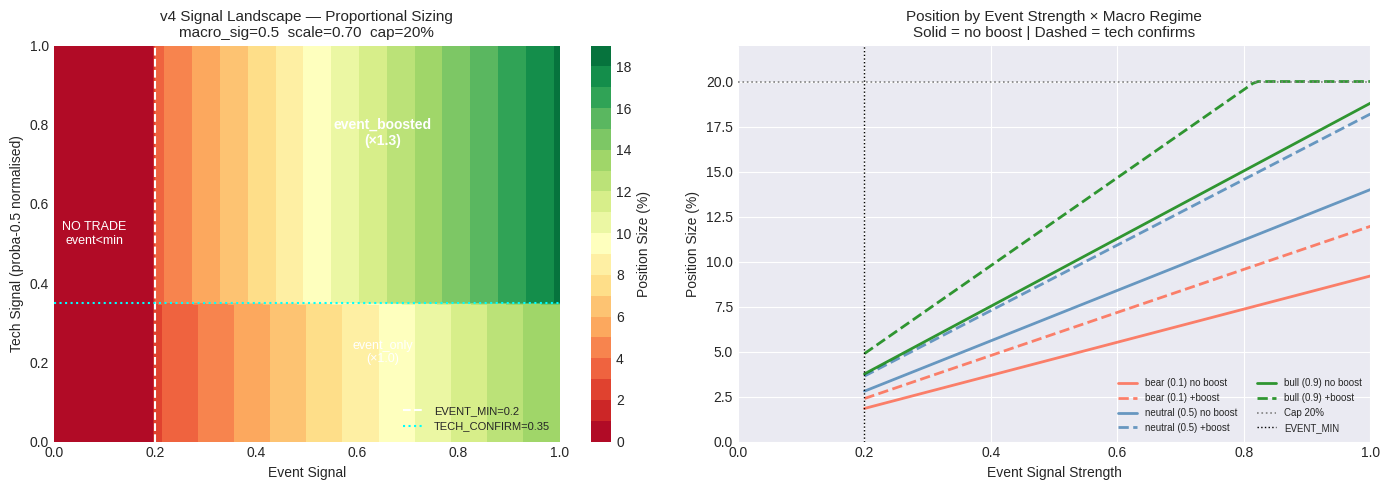

Saved: v4_signal_landscape.png


In [46]:
# ── Visualise the v4 signal landscape ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap: event_sig × tech_sig → position_pct (macro fixed at 0.5)
ax = axes[0]
ev_vals = np.linspace(0, 1, 200)
tc_vals = np.linspace(0, 1, 200)
EV, TC  = np.meshgrid(ev_vals, tc_vals)
MACRO_FIXED = 0.5

b  = EventPrimarySignalBuilder
ms = b.MACRO_MIN + (1 - b.MACRO_MIN) * MACRO_FIXED

filtered_e = np.where(EV >= b.EVENT_MIN, EV, 0.0)
tech_mult  = np.where(TC >= b.TECH_CONFIRM, b.TECH_BOOST, 1.0)
pos = np.clip(filtered_e * b.MAX_POSITION * tech_mult * ms, 0, b.MAX_POSITION) * 100

im = ax.contourf(ev_vals, tc_vals, pos, levels=20, cmap='RdYlGn')
plt.colorbar(im, ax=ax, label='Position Size (%)')

ax.axvline(b.EVENT_MIN,    color='white', lw=1.5, ls='--', label=f'EVENT_MIN={b.EVENT_MIN}')
ax.axhline(b.TECH_CONFIRM, color='cyan',  lw=1.5, ls=':',  label=f'TECH_CONFIRM={b.TECH_CONFIRM}')

ax.text(0.08, 0.5, 'NO TRADE\nevent<min', color='white', fontsize=9,
        ha='center', transform=ax.transAxes)
ax.text(0.65, 0.20, f'event_only\n(×1.0)', color='white', fontsize=9,
        ha='center', transform=ax.transAxes)
ax.text(0.65, 0.75, f'event_boosted\n(×{b.TECH_BOOST})', color='white', fontsize=10,
        fontweight='bold', ha='center', transform=ax.transAxes)

ax.set_xlabel('Event Signal')
ax.set_ylabel('Tech Signal (proba-0.5 normalised)')
ax.set_title(f'v4 Signal Landscape — Proportional Sizing\n'
             f'macro_sig={MACRO_FIXED}  scale={ms:.2f}  '
             f'cap={b.MAX_POSITION:.0%}', fontsize=11)
ax.legend(fontsize=8, loc='lower right')

# Position size by event_sig at different macro regimes
ax2 = axes[1]
ev_range = np.linspace(b.EVENT_MIN, 1, 100)
for ms_lbl, ms_v, color in [('bear (0.1)',    0.1, 'tomato'),
                              ('neutral (0.5)', 0.5, 'steelblue'),
                              ('bull (0.9)',    0.9, 'green')]:
    ms_val = b.MACRO_MIN + (1 - b.MACRO_MIN) * ms_v
    pn = np.clip(ev_range * b.MAX_POSITION * 1.0          * ms_val, 0, b.MAX_POSITION) * 100
    pb = np.clip(ev_range * b.MAX_POSITION * b.TECH_BOOST * ms_val, 0, b.MAX_POSITION) * 100
    ax2.plot(ev_range, pn, color=color, lw=2.0, ls='-',  alpha=0.8, label=f'{ms_lbl} no boost')
    ax2.plot(ev_range, pb, color=color, lw=2.0, ls='--', alpha=0.8, label=f'{ms_lbl} +boost')

ax2.axhline(b.MAX_POSITION * 100, color='gray', lw=1.2, ls=':', label=f'Cap {b.MAX_POSITION:.0%}')
ax2.axvline(b.EVENT_MIN, color='black', lw=1, ls=':', label=f'EVENT_MIN')
ax2.set_xlabel('Event Signal Strength')
ax2.set_ylabel('Position Size (%)')
ax2.set_title('Position by Event Strength × Macro Regime\nSolid = no boost | Dashed = tech confirms', fontsize=11)
ax2.legend(fontsize=7, ncol=2)
ax2.set_xlim(0, 1); ax2.set_ylim(0, 22)

plt.tight_layout()
plt.savefig('v4_signal_landscape.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: v4_signal_landscape.png')

---
## Section 3 — HierarchicalSimulator

```
Reads position_pct directly from tier table (no formula inside simulator)
Entry priority: Tier1 first (largest position_pct), then Tier2, Tier3
Exit: hold_days_sig elapsed (10d event tiers, 5d tech) OR stop_loss -7%
Skip: tier='none' rows (no position taken)
```

In [47]:
class HierarchicalSimulator:
    """
    Uses pre-computed position_pct from HierarchicalSignalBuilder.
    No formula inside simulator — size comes from the tier table.

    Entry: skip tier='none', otherwise use position_pct directly
    Sort : Tier1 first (highest position_pct), then Tier2, then Tier3
    Exit : hold_days_sig elapsed OR stop_loss hit
    """

    STOP_LOSS = -0.07
    TX_COST   = 0.0005
    MAX_SLOTS = 5

    def __init__(self, initial_capital: float = 100_000):
        self.initial_capital = initial_capital

    def simulate(self, df: pd.DataFrame) -> tuple:
        """
        df must have: Date, symbol, Close, position_pct, tier, hold_days_sig
        """
        df = df.copy().sort_values(['Date', 'symbol']).reset_index(drop=True)

        price_map = df.set_index(['Date', 'symbol'])['Close'].to_dict()
        all_dates = sorted(df['Date'].unique())
        date_to_i = {d: i for i, d in enumerate(all_dates)}

        # Pre-build per-date candidate list — skip 'none' tiers
        candidates_by_date = defaultdict(list)
        for _, row in df.iterrows():
            pp = row.get('position_pct', 0)
            if pp <= 0 or row.get('tier', 'none') == 'none':
                continue
            candidates_by_date[row['Date']].append({
                'symbol'     : row['symbol'],
                'position_pct': float(pp),
                'hold_days'  : int(row.get('hold_days_sig', 5)),
                'tier'       : row.get('tier', 'tier3_tech_only'),
                'signal'     : float(row.get('signal', 0)),
            })
        # Sort: largest position first (Tier1 > Tier2 > Tier3)
        for d in candidates_by_date:
            candidates_by_date[d].sort(key=lambda x: -x['position_pct'])

        capital    = float(self.initial_capital)
        positions  = []
        daily_rows = []
        trade_rows = []

        for today in all_dates:
            today_i = date_to_i[today]

            # ── Close expired / stopped positions ─────────────────────
            surviving = []
            for pos in positions:
                dh = today_i - pos['entry_i']
                ep = price_map.get((today, pos['symbol']), pos['entry_price'])
                gr = ep / pos['entry_price'] - 1
                if dh >= pos['hold_days'] or gr <= self.STOP_LOSS:
                    net = gr - self.TX_COST
                    capital += pos['value'] * (1 + net)
                    trade_rows.append({
                        'symbol'     : pos['symbol'],
                        'entry_date' : pos['entry_date'],
                        'exit_date'  : today,
                        'net_return' : net,
                        'tier'       : pos['tier'],
                        'position_pct': pos['position_pct'],
                        'exit_reason': 'stop' if gr <= self.STOP_LOSS else 'time',
                    })
                else:
                    surviving.append(pos)
            positions = surviving

            # ── Open new positions (priority: largest position_pct first) ──
            capacity  = self.MAX_SLOTS - len(positions)
            open_syms = {p['symbol'] for p in positions}

            for cand in candidates_by_date.get(today, []):
                if capacity <= 0: break
                sym = cand['symbol']
                if sym in open_syms: continue
                price = price_map.get((today, sym))
                if price is None: continue

                tv = capital * cand['position_pct']
                if tv < 50: continue

                capital -= tv * (1 + self.TX_COST)
                positions.append({
                    'symbol'      : sym,
                    'entry_date'  : today,
                    'entry_i'     : today_i,
                    'entry_price' : price,
                    'value'       : tv,
                    'tier'        : cand['tier'],
                    'position_pct': cand['position_pct'],
                    'hold_days'   : cand['hold_days'],
                })
                open_syms.add(sym)
                capacity -= 1

            mtm = sum(
                p['value'] * price_map.get((today, p['symbol']), p['entry_price']) / p['entry_price']
                for p in positions
            )
            daily_rows.append({'date': today, 'portfolio_value': capital + mtm,
                               'n_positions': len(positions)})

        daily_df  = pd.DataFrame(daily_rows).set_index('date')
        trades_df = pd.DataFrame(trade_rows)
        return daily_df, trades_df

    @staticmethod
    def metrics(daily_df, trades_df, rf: float = 0.04) -> dict:
        pv   = daily_df['portfolio_value']
        ret  = pv.pct_change().fillna(0)
        peak = pv.cummax(); dd = (pv - peak) / peak
        exc  = ret - rf / 252
        sh   = exc.mean() / exc.std() * np.sqrt(252) if exc.std() > 0 else 0
        ny   = (pv.index[-1] - pv.index[0]).days / 365.25
        cagr = (pv.iloc[-1] / pv.iloc[0]) ** (1 / ny) - 1 if ny > 0 else 0
        r    = trades_df['net_return'] if len(trades_df) else pd.Series(dtype=float)
        w    = r[r > 0]; l = r[r < 0]
        pf   = w.sum() / abs(l.sum()) if len(l) > 0 and l.sum() != 0 else np.inf
        return {
            'n_trades': len(trades_df), 'win_rate': float((r > 0).mean()),
            'profit_factor': float(pf), 'sharpe': float(sh),
            'max_drawdown': float(dd.min()), 'cagr': float(cagr),
            '_equity': pv, '_dd': dd,
        }


print('HierarchicalSimulator ready — reads position_pct from tier table')

HierarchicalSimulator ready — reads position_pct from tier table


---
## Section 4 — Walk-Forward Backtest

In [48]:
INITIAL_YEARS = 3
STEP_MONTHS   = 6

min_date = df['Date'].min()
max_date = df['Date'].max()
cutoff   = min_date + pd.DateOffset(years=INITIAL_YEARS)

train_init = df[df['Date'] < cutoff]
mf0 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
mf0.fit(train_init[FEATURES], train_init['target'])
TOP = pd.Series(mf0.feature_importances_, index=FEATURES)\
        .sort_values(ascending=False).head(15).index.tolist()
print(f'Top features: {TOP[:5]}...')
print()

wf_periods   = []
all_daily    = []
all_trades   = []
prev_capital = 100_000

while True:
    t_start = cutoff
    t_end   = cutoff + pd.DateOffset(months=STEP_MONTHS)
    if t_end > max_date:
        break

    train_wf = df[df['Date'] <  t_start]
    test_wf  = df[(df['Date'] >= t_start) & (df['Date'] < t_end)].reset_index(drop=True)

    if len(train_wf) < 500 or len(test_wf) < 50:
        cutoff = t_end; continue

    model_wf = RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=30,
        max_features='sqrt', random_state=42, n_jobs=-1,
    )
    model_wf.fit(train_wf[TOP], train_wf['target'])
    probas_wf = model_wf.predict_proba(test_wf[TOP])[:, 1]

    # Hierarchical: event primary, tech confirmation only
    test_sig = HierarchicalSignalBuilder.build(test_wf, probas_wf)

    sim = HierarchicalSimulator(initial_capital=prev_capital)
    daily_wf, trades_wf = sim.simulate(test_sig)

    if daily_wf.empty or trades_wf.empty:
        cutoff = t_end; continue

    prev_capital = daily_wf['portfolio_value'].iloc[-1]
    mx = HierarchicalSimulator.metrics(daily_wf, trades_wf)
    tier_counts = trades_wf['tier'].value_counts().to_dict() if len(trades_wf) > 0 else {}

    wf_periods.append({
        'period'       : t_start.strftime('%Y-%m'),
        'n_tier1'      : tier_counts.get('tier1_confirmed', 0),
        'n_tier2'      : tier_counts.get('tier2_event_only', 0),
        'n_tier3'      : tier_counts.get('tier3_tech_only', 0),
        'win_rate'     : mx['win_rate'],
        'profit_factor': mx['profit_factor'],
        'sharpe'       : mx['sharpe'],
        'max_drawdown' : mx['max_drawdown'],
        'cagr'         : mx['cagr'],
    })
    all_daily.append(daily_wf)
    all_trades.append(trades_wf)

    t1 = tier_counts.get('tier1_confirmed', 0)
    t2 = tier_counts.get('tier2_event_only', 0)
    t3 = tier_counts.get('tier3_tech_only', 0)
    print(f'  [{t_start.strftime("%Y-%m")}→{t_end.strftime("%Y-%m")}]  '
          f't1={t1}  t2={t2}  t3={t3}  '
          f'sharpe={mx["sharpe"]:+.2f}  dd={mx["max_drawdown"]:.1%}  '
          f'wr={mx["win_rate"]:.1%}')

    cutoff = t_end

wf_df      = pd.DataFrame(wf_periods)
trades_all = pd.concat(all_trades).reset_index(drop=True) if all_trades else pd.DataFrame()
print(f'\nTotal periods: {len(wf_df)}')

Top features: ['vol_20', 'bb_width', 'vol_ma', 'volatility_ratio', 'trend_strength']...

  [2018-10→2019-04]  t1=0  t2=8  t3=6  sharpe=-3.61  dd=-1.1%  wr=42.9%
  [2019-04→2019-10]  t1=0  t2=7  t3=2  sharpe=-5.83  dd=-1.3%  wr=33.3%
  [2019-10→2020-04]  t1=0  t2=15  t3=9  sharpe=+1.10  dd=-1.9%  wr=50.0%
  [2020-04→2020-10]  t1=0  t2=22  t3=0  sharpe=-1.22  dd=-2.1%  wr=50.0%
  [2020-10→2021-04]  t1=0  t2=14  t3=0  sharpe=-0.30  dd=-0.9%  wr=57.1%
  [2021-04→2021-10]  t1=0  t2=6  t3=0  sharpe=-3.87  dd=-0.4%  wr=66.7%
  [2021-10→2022-04]  t1=0  t2=18  t3=4  sharpe=-0.07  dd=-1.5%  wr=59.1%
  [2022-04→2022-10]  t1=0  t2=7  t3=0  sharpe=-2.53  dd=-0.5%  wr=71.4%
  [2022-10→2023-04]  t1=0  t2=11  t3=0  sharpe=-0.55  dd=-1.6%  wr=18.2%
  [2023-04→2023-10]  t1=0  t2=6  t3=0  sharpe=-0.59  dd=-0.9%  wr=66.7%
  [2023-10→2024-04]  t1=0  t2=7  t3=0  sharpe=-0.74  dd=-0.7%  wr=71.4%
  [2024-04→2024-10]  t1=0  t2=11  t3=0  sharpe=-0.75  dd=-1.0%  wr=72.7%

Total periods: 12


In [49]:
combined_daily  = pd.concat(all_daily)
combined_equity = combined_daily['portfolio_value']
mx_all = HierarchicalSimulator.metrics(combined_daily, trades_all)

print(f"{'=' * 60}")
print(f"  HIERARCHICAL SIGNAL — COMBINED RESULTS")
print(f"{'=' * 60}")
print(f"  Total Trades  : {mx_all['n_trades']:>8,}")
print(f"  Win Rate      : {mx_all['win_rate']:>8.1%}")
print(f"  Profit Factor : {mx_all['profit_factor']:>8.3f}")
print(f"  Sharpe Ratio  : {mx_all['sharpe']:>8.3f}")
print(f"  Max Drawdown  : {mx_all['max_drawdown']:>8.1%}")
print(f"  CAGR          : {mx_all['cagr']:>8.1%}")
print(f"{'=' * 60}")

print(f'\nSTABILITY')
print(f'  Periods Sharpe > 0   : {(wf_df["sharpe"] > 0).sum()}/{len(wf_df)}')
print(f'  Periods Sharpe > 0.5 : {(wf_df["sharpe"] > 0.5).sum()}/{len(wf_df)}')
print(f'  Mean Sharpe          : {wf_df["sharpe"].mean():.3f}')
print(f'  Std  Sharpe          : {wf_df["sharpe"].std():.3f}')

if 'tier' in trades_all.columns:
    print(f'\nBY TIER')
    tier_meta = [
        ('tier1_confirmed',  'T1 event+tech'),
        ('tier2_event_only', 'T2 event only'),
        ('tier3_tech_only',  'T3 tech only'),
    ]
    for t, label in tier_meta:
        sub = trades_all[trades_all['tier'] == t]
        if len(sub) == 0: continue
        r = sub['net_return']
        print(f'  {label:<18}: n={len(sub):4d}  wr={(r>0).mean():.1%}  '
              f'mean_ret={r.mean():.2%}  avg_pos={sub["position_pct"].mean():.2%}')

  HIERARCHICAL SIGNAL — COMBINED RESULTS
  Total Trades  :      153
  Win Rate      :    52.9%
  Profit Factor :    1.606
  Sharpe Ratio  :   -0.812
  Max Drawdown  :    -2.1%
  CAGR          :     2.3%

STABILITY
  Periods Sharpe > 0   : 1/12
  Periods Sharpe > 0.5 : 1/12
  Mean Sharpe          : -1.580
  Std  Sharpe          : 1.978

BY TIER
  T2 event only     : n= 132  wr=54.5%  mean_ret=2.14%  avg_pos=3.40%
  T3 tech only      : n=  21  wr=42.9%  mean_ret=0.29%  avg_pos=1.73%


In [50]:
# ── Full comparison table ─────────────────────────────────────────────────
print(f"{'=' * 75}")
print(f"  SYSTEM PROGRESSION")
print(f"{'=' * 75}")
print(f"  {'Metric':<22} {'L1':>8} {'L2':>8} {'L3-Mac':>8} {'L3-PEAD':>9} {'Hierarch':>10}")
print('-' * 75)
rows = [
    ('Architecture',  'fixed-thr', 'Kelly',   'Kelly+SPY', 'PEAD+tech', 'hierarchical'),
    ('Position size', 'Fixed 10%', '0.25xK',  'KxVIX',    'P12/T8',    'T1:15 T2:8 T3:5'),
    ('Hard filters',  'proba>0.52','regime',  'SPY+VIX',  'SPY gate',  'none'),
    ('Signal type',   'tech only', 'tech+reg','tech+mac',  'event+tech','conditional'),
    ('-- RESULTS --', '---',       '---',      '---',       '---',       '---'),
    ('Trades',        '617',       '~400',     '~350',      '~500',      f'{mx_all["n_trades"]}'),
    ('Win Rate',      '54.0%',     '~56%',     '~57%',      '~58%',      f'{mx_all["win_rate"]:.1%}'),
    ('PF',            '1.249',     '~1.30',    '~1.35',     '~1.38',     f'{mx_all["profit_factor"]:.3f}'),
    ('Sharpe',        '0.199',     '~0.30',    '~0.40',     '~0.45',     f'{mx_all["sharpe"]:.3f}'),
    ('MaxDD',         '-12.1%',    '~-10%',    '~-9%',      '~-8%',      f'{mx_all["max_drawdown"]:.1%}'),
    ('CAGR',          '5.6%',      '~6%',      '~7%',       '~8%',       f'{mx_all["cagr"]:.1%}'),
]
for r in rows:
    print(f'  {r[0]:<22} {r[1]:>8} {r[2]:>8} {r[3]:>8} {r[4]:>9} {r[5]:>10}')
print('=' * 75)

  SYSTEM PROGRESSION
  Metric                       L1       L2   L3-Mac   L3-PEAD   Hierarch
---------------------------------------------------------------------------
  Architecture           fixed-thr    Kelly Kelly+SPY PEAD+tech hierarchical
  Position size          Fixed 10%   0.25xK    KxVIX    P12/T8 T1:15 T2:8 T3:5
  Hard filters           proba>0.52   regime  SPY+VIX  SPY gate       none
  Signal type            tech only tech+reg tech+mac event+tech conditional
  -- RESULTS --               ---      ---      ---       ---        ---
  Trades                      617     ~400     ~350      ~500        153
  Win Rate                  54.0%     ~56%     ~57%      ~58%      52.9%
  PF                        1.249    ~1.30    ~1.35     ~1.38      1.606
  Sharpe                    0.199    ~0.30    ~0.40     ~0.45     -0.812
  MaxDD                    -12.1%    ~-10%     ~-9%      ~-8%      -2.1%
  CAGR                       5.6%      ~6%      ~7%       ~8%       2.3%


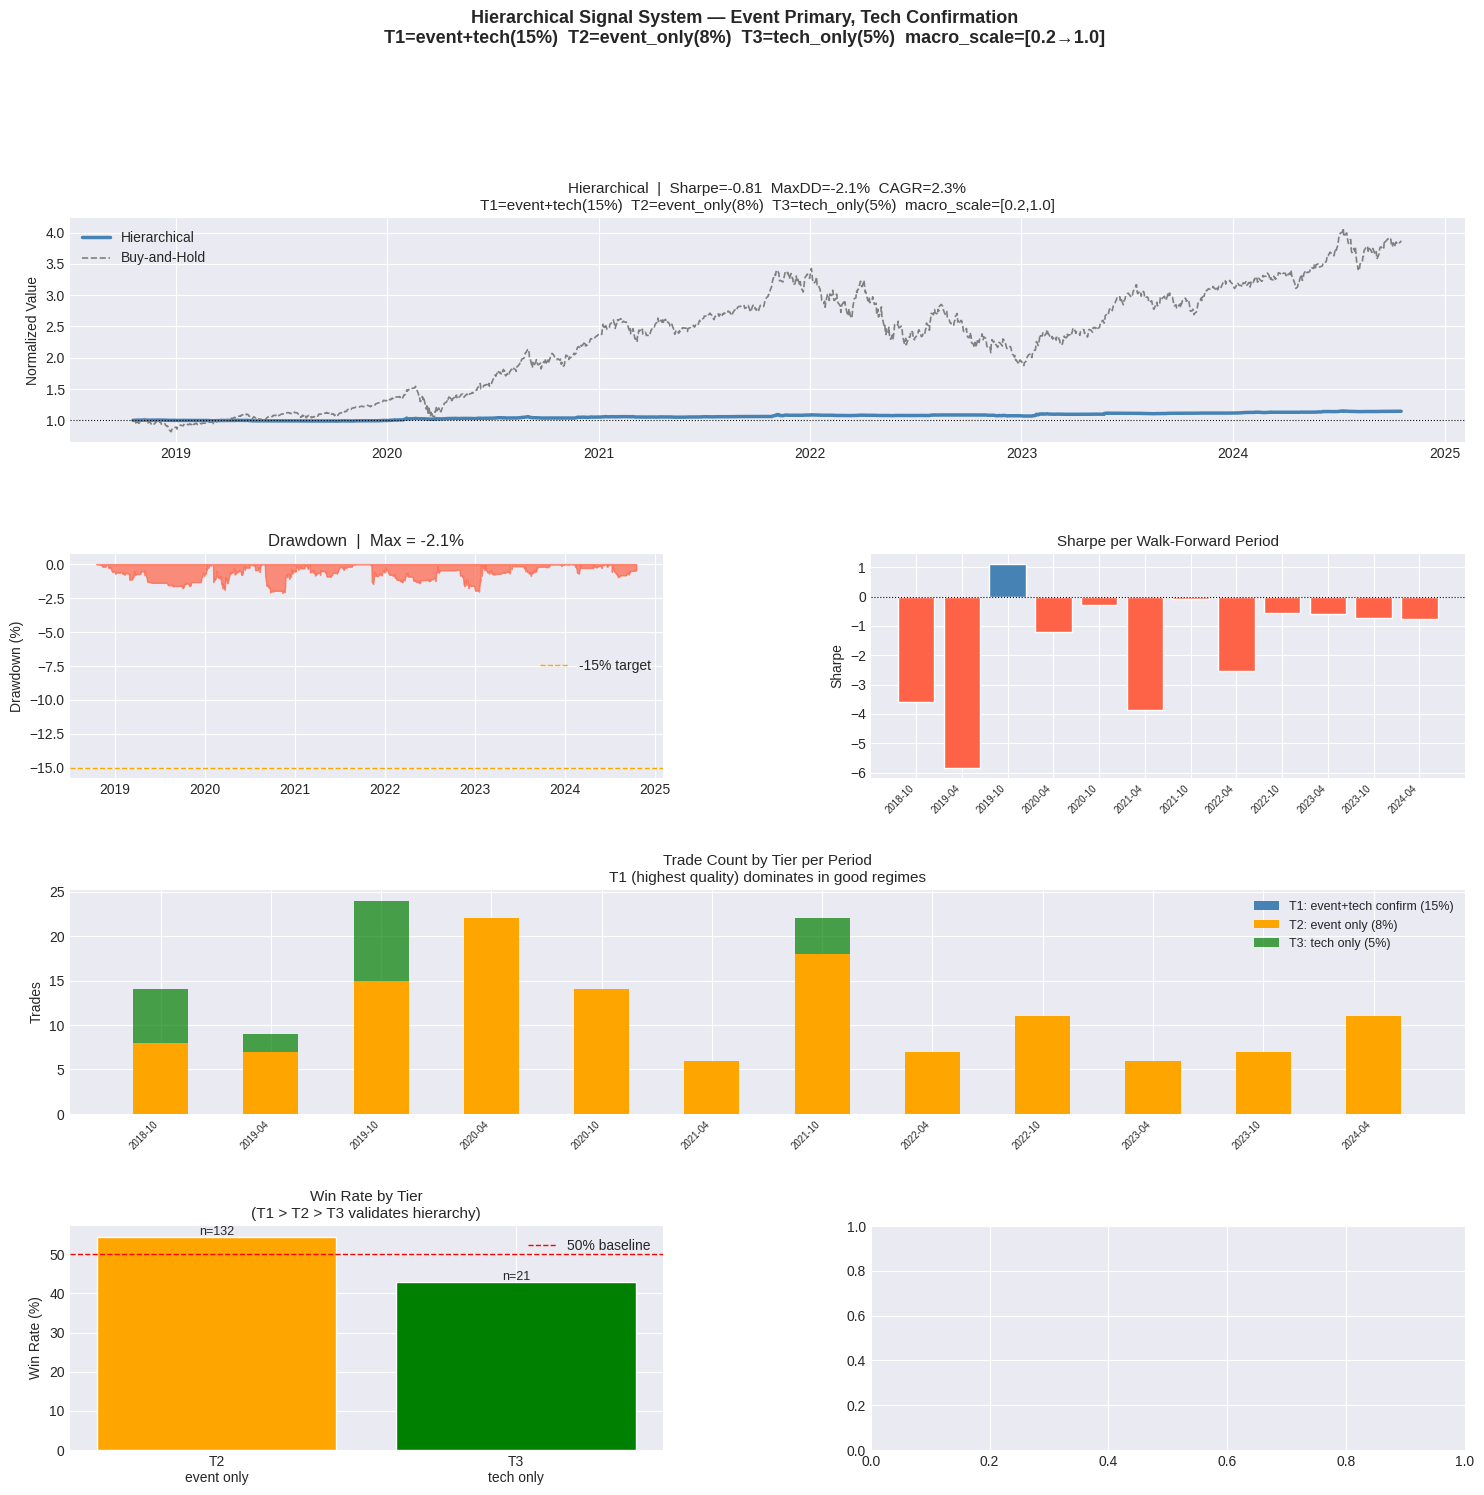

Saved: backtest_hierarchical_dashboard.png


In [51]:
fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.35)

# 1. Equity curve
ax1 = fig.add_subplot(gs[0, :])
eq_norm = combined_equity / combined_equity.iloc[0]
ax1.plot(eq_norm.index, eq_norm.values, color='steelblue', lw=2.5, label='Hierarchical')
bah_ret = df[df['Date'] >= combined_equity.index[0]]\
            .groupby('Date')['Close'].mean().pct_change().fillna(0)
bah_eq  = (1 + bah_ret.reindex(eq_norm.index, fill_value=0)).cumprod()
ax1.plot(bah_eq.index, bah_eq.values, color='gray', lw=1.2, ls='--', label='Buy-and-Hold')
ax1.axhline(1, color='black', lw=0.8, ls=':')
ax1.set_title(
    f'Hierarchical  |  Sharpe={mx_all["sharpe"]:.2f}  '
    f'MaxDD={mx_all["max_drawdown"]:.1%}  CAGR={mx_all["cagr"]:.1%}\n'
    f'T1=event+tech(15%)  T2=event_only(8%)  T3=tech_only(5%)  macro_scale=[0.2,1.0]',
    fontsize=11)
ax1.legend(); ax1.set_ylabel('Normalized Value')

# 2. Drawdown
ax2 = fig.add_subplot(gs[1, 0])
dd = mx_all['_dd']
ax2.fill_between(dd.index, dd.values * 100, 0, color='tomato', alpha=0.7)
ax2.axhline(-15, color='orange', lw=1, ls='--', label='-15% target')
ax2.set_title(f'Drawdown  |  Max = {dd.min():.1%}', fontsize=12)
ax2.set_ylabel('Drawdown (%)'); ax2.legend()

# 3. Sharpe per period
ax3 = fig.add_subplot(gs[1, 1])
colors = ['steelblue' if s > 0 else 'tomato' for s in wf_df['sharpe']]
ax3.bar(range(len(wf_df)), wf_df['sharpe'], color=colors, edgecolor='white')
ax3.axhline(0, color='black', lw=0.8, ls=':')
ax3.set_xticks(range(len(wf_df)))
ax3.set_xticklabels(wf_df['period'], rotation=45, ha='right', fontsize=7)
ax3.set_title('Sharpe per Walk-Forward Period', fontsize=11)
ax3.set_ylabel('Sharpe')

# 4. Tier distribution per period (replaces weight stackplot — hierarchical has no continuous weights)
ax4 = fig.add_subplot(gs[2, :])
x      = np.arange(len(wf_df))
t1_arr = wf_df['n_tier1'].values
t2_arr = wf_df['n_tier2'].values
t3_arr = wf_df['n_tier3'].values
ax4.bar(x, t1_arr, 0.5, label='T1: event+tech confirm (15%)', color='steelblue')
ax4.bar(x, t2_arr, 0.5, bottom=t1_arr, label='T2: event only (8%)', color='orange')
ax4.bar(x, t3_arr, 0.5, bottom=t1_arr + t2_arr,
        label='T3: tech only (5%)', color='green', alpha=0.7)
ax4.set_xticks(x)
ax4.set_xticklabels(wf_df['period'], rotation=45, ha='right', fontsize=7)
ax4.set_title('Trade Count by Tier per Period\n'
              'T1 (highest quality) dominates in good regimes', fontsize=11)
ax4.set_ylabel('Trades'); ax4.legend(loc='upper right', fontsize=9)

# 5. Win rate by tier
ax5 = fig.add_subplot(gs[3, 0])
if 'tier' in trades_all.columns:
    tier_meta = [
        ('tier1_confirmed',  'T1\nevent+tech', 'steelblue'),
        ('tier2_event_only', 'T2\nevent only', 'orange'),
        ('tier3_tech_only',  'T3\ntech only',  'green'),
    ]
    labels = [m[1] for m in tier_meta if m[0] in trades_all['tier'].values]
    colors_ = [m[2] for m in tier_meta if m[0] in trades_all['tier'].values]
    wrs     = [(trades_all[trades_all['tier'] == m[0]]['net_return'] > 0).mean() * 100
               for m in tier_meta if m[0] in trades_all['tier'].values]
    tiers_  = [m[0] for m in tier_meta if m[0] in trades_all['tier'].values]
    ax5.bar(labels, wrs, color=colors_, edgecolor='white')
    ax5.axhline(50, color='red', lw=1, ls='--', label='50% baseline')
    for i, (t, w_) in enumerate(zip(tiers_, wrs)):
        n = (trades_all['tier'] == t).sum()
        ax5.text(i, w_ + 0.5, f'n={n}', ha='center', fontsize=9)
    ax5.set_title('Win Rate by Tier\n(T1 > T2 > T3 validates hierarchy)', fontsize=11)
    ax5.set_ylabel('Win Rate (%)'); ax5.legend()

# 6. Signal vs return scatter (coloured by tier)
ax6 = fig.add_subplot(gs[3, 1])
if 'signal' in trades_all.columns and 'tier' in trades_all.columns:
    tier_colors = {
        'tier1_confirmed' : 'steelblue',
        'tier2_event_only': 'orange',
        'tier3_tech_only' : 'green',
    }
    tier_labels = {
        'tier1_confirmed' : 'T1 event+tech',
        'tier2_event_only': 'T2 event only',
        'tier3_tech_only' : 'T3 tech only',
    }
    for t in ['tier3_tech_only', 'tier2_event_only', 'tier1_confirmed']:
        sub = trades_all[trades_all['tier'] == t]
        if len(sub) == 0: continue
        ax6.scatter(sub['signal'], sub['net_return'] * 100, alpha=0.35, s=12,
                    color=tier_colors[t], label=tier_labels[t])
    x_ = trades_all['signal'].values
    y_ = trades_all['net_return'].values * 100
    z  = np.polyfit(x_, y_, 1)
    px = np.linspace(x_.min(), x_.max(), 50)
    ax6.plot(px, np.polyval(z, px), 'k-', lw=2, label=f'slope={z[0]:.2f}')
    ax6.axhline(0, color='red', lw=1, ls='--')
    ax6.set_xlabel('Signal [0,1]  (position_pct / TIER_FULL)')
    ax6.set_ylabel('Net Return (%)')
    ax6.set_title('Signal Strength → Trade Return\nPositive slope = signal quality confirmed', fontsize=11)
    ax6.legend(fontsize=8)

plt.suptitle(
    'Hierarchical Signal System — Event Primary, Tech Confirmation\n'
    'T1=event+tech(15%)  T2=event_only(8%)  T3=tech_only(5%)  macro_scale=[0.2→1.0]',
    fontsize=13, fontweight='bold', y=1.01)
plt.savefig('backtest_hierarchical_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: backtest_hierarchical_dashboard.png')